In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,81145628,Movie,Norm of the North: King Sized Adventure,"Richard Finn, Tim Maltby","Alan Marriott, Andrew Toth, Brian Dobson, Cole...","United States, India, South Korea, China","September 9, 2019",2019,TV-PG,90 min,"Children & Family Movies, Comedies",Before planning an awesome wedding for his gra...
1,80117401,Movie,Jandino: Whatever it Takes,NaN,Jandino Asporaat,United Kingdom,"September 9, 2016",2016,TV-MA,94 min,Stand-Up Comedy,Jandino Asporaat riffs on the challenges of ra...
2,70234439,TV Show,Transformers Prime,NaN,"Peter Cullen, Sumalee Montano, Frank Welker, J...",United States,"September 8, 2018",2013,TV-Y7-FV,1 Season,Kids' TV,"With the help of three human allies, the Autob..."
3,80058654,TV Show,Transformers: Robots in Disguise,NaN,"Will Friedle, Darren Criss, Constance Zimmer, ...",United States,"September 8, 2018",2016,TV-Y7,1 Season,Kids' TV,When a prison ship crash unleashes hundreds of...
4,80125979,Movie,#realityhigh,Fernando Lebrija,"Nesta Cooper, Kate Walsh, John Michael Higgins...",United States,"September 8, 2017",2017,TV-14,99 min,Comedies,When nerdy high schooler Dani finally attracts...


In [9]:
# Check null values
df.isnull().sum()

# Fill missing values (Correct way)
df['country'] = df['country'].fillna('Unknown')
df['director'] = df['director'].fillna('No Director')

# Convert date column
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year
df['year_added'] = df['date_added'].dt.year

In [10]:
df['type'].value_counts()
df['country'].value_counts().head(10)
df['year_added'].value_counts().sort_index()
df['listed_in'].value_counts().head(10)

listed_in
Documentaries                                       299
Stand-Up Comedy                                     273
Dramas, International Movies                        248
Dramas, Independent Movies, International Movies    186
Comedies, Dramas, International Movies              174
Kids' TV                                            159
Documentaries, International Movies                 150
Children & Family Movies, Comedies                  129
Children & Family Movies                            120
Comedies, International Movies                      120
Name: count, dtype: int64

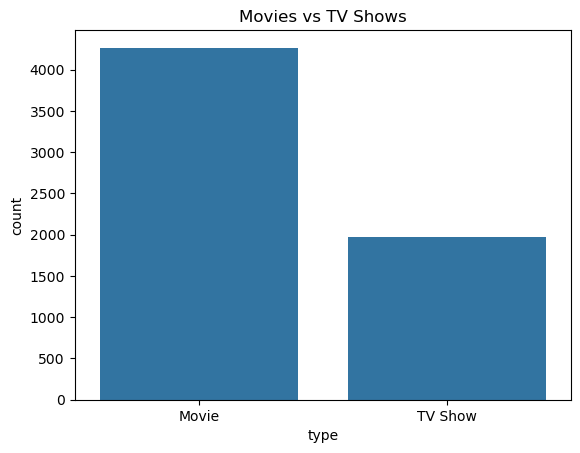

In [11]:
# Movies vs TV Shows
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()


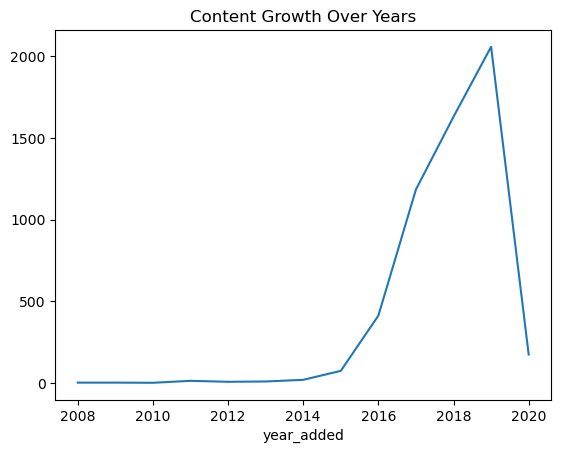

In [12]:
# Growth over years
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Growth Over Years")
plt.show()

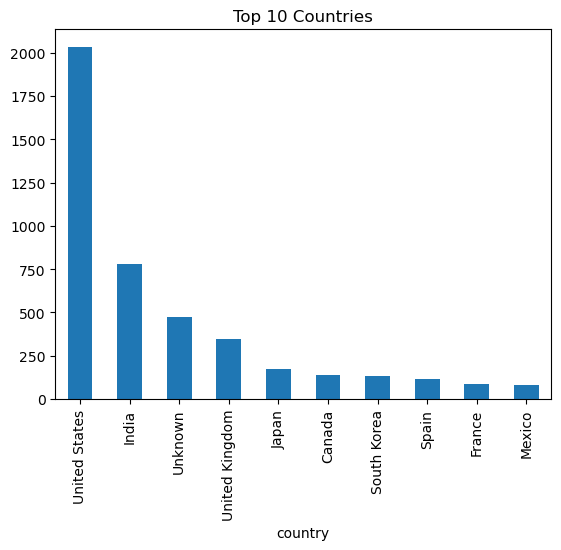

In [13]:
# Top countries
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Countries")
plt.show()

In [19]:
df['duration'].value_counts().head()

duration
1 Season     1321
2 Seasons     304
3 Seasons     158
90 min        111
91 min        104
Name: count, dtype: int64

In [15]:
df[df['country'] == 'India'].head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
35,81154455,Movie,Article 15,Anubhav Sinha,"Ayushmann Khurrana, Nassar, Manoj Pahwa, Kumud...",India,2019-09-06,2019,TV-MA,125 min,"Dramas, International Movies, Thrillers",The grim realities of caste discrimination com...,2019.0
37,81052275,Movie,Ee Nagaraniki Emaindi,Tharun Bhascker,"Vishwaksen Naidu, Sushanth Reddy, Abhinav Goma...",India,2019-09-06,2018,TV-14,133 min,"Comedies, International Movies","In Goa and in desperate need of cash, four chi...",2019.0
41,70303496,Movie,PK,Rajkumar Hirani,"Aamir Khan, Anuskha Sharma, Sanjay Dutt, Saura...",India,2018-09-06,2014,TV-14,146 min,"Comedies, Dramas, International Movies",Aamir Khan teams with director Rajkumar Hirani...,2018.0
58,81155784,Movie,Watchman,A. L. Vijay,"G.V. Prakash Kumar, Samyuktha Hegde, Suman, Ra...",India,2019-09-04,2019,TV-14,93 min,"Comedies, Dramas, International Movies","Rushing to pay off a loan shark, a young man b...",2019.0
99,80225885,TV Show,Bard of Blood,No Director,"Emraan Hashmi, Viineet Kumar, Sobhita Dhulipal...",India,2019-09-27,2019,TV-MA,1 Season,"International TV Shows, TV Action & Adventure,...","Years after a disastrous job in Balochistan, a...",2019.0


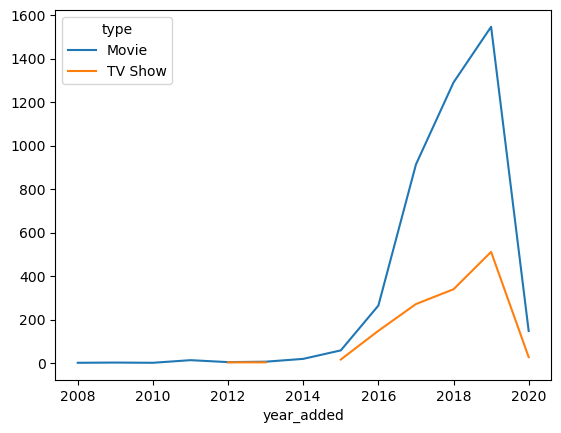

In [16]:
df.groupby(['year_added', 'type']).size().unstack().plot()
plt.show()

Insights:
1. Netflix has more movies than TV shows, indicating a focus on movie content.
2. Content production increased significantly after 2015, showing rapid platform growth.
3. The USA contributes the highest number of titles, highlighting its dominance in content creation.
4. Drama and international genres are most popular, reflecting audience preferences.
5. Most Netflix movies are around 90–100 minutes.
6. India has growing content contribution on Netflix.
7. Movies increased faster than TV shows over time.
   